Adding physical features 

# Load Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from utils.data_loader import load_parquet
from sklearn.model_selection import TimeSeriesSplit, BaseCrossValidator
import numpy as np

# Load only specific columns needed for analysis
columns_needed = ['time', 'orbital_decay', '|avg B|', 'F10.7 (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 4)
                 time  orbital_decay   |avg B|  F10.7 (LASP)
0 2023-01-01 00:00:00        16.6730  5.630000         153.0
1 2023-01-01 00:00:20        16.6730  5.633333         153.0
2 2023-01-01 00:00:40        16.6735  5.636667         153.0
3 2023-01-01 00:01:00        16.6740  5.640000         153.0
4 2023-01-01 00:01:20        16.6740  5.633333         153.0


# 1. Select a subset

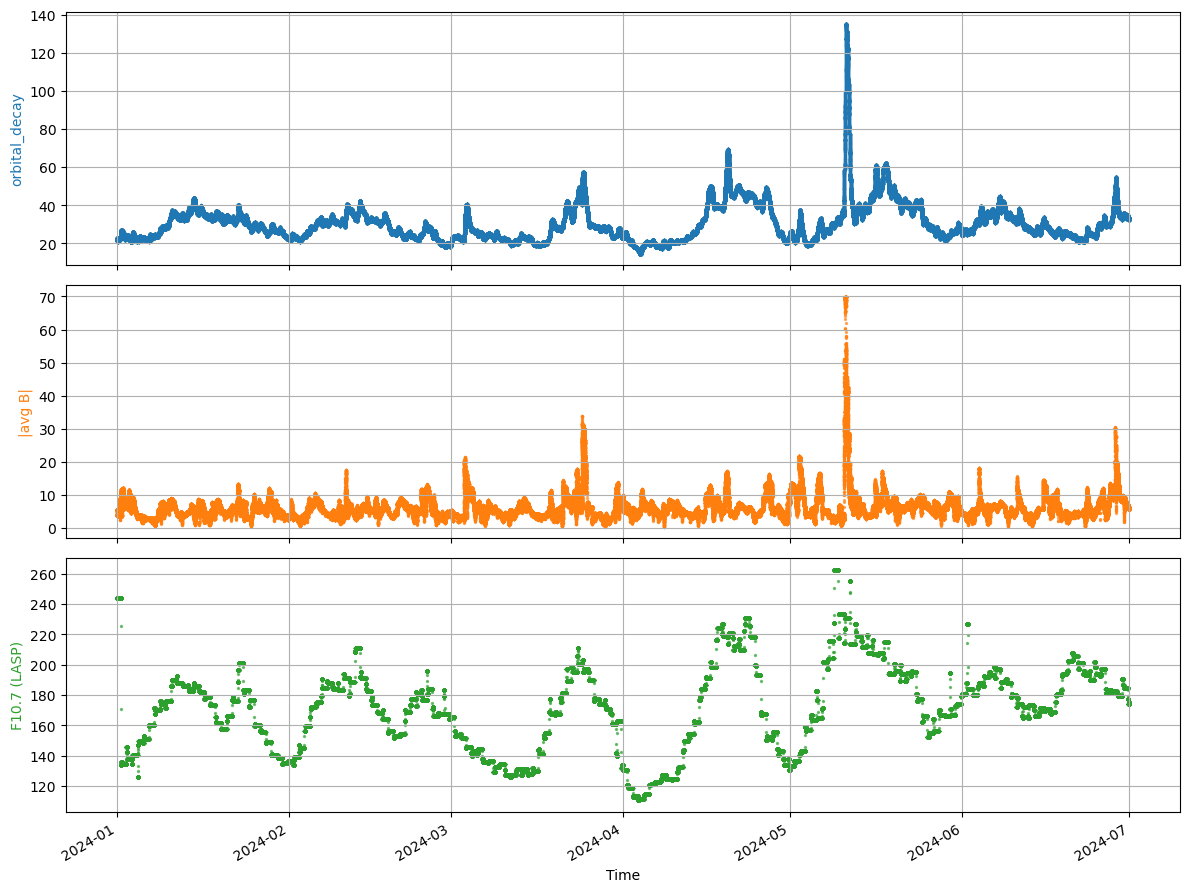

In [2]:
from utils.plot_loader import create_subset
# =========================== Input ===================================
start_date = '2024-01-01 00:00:00'
end_date = '2024-07-01 00:00:00'
# =====================================================================

subset = create_subset(GFOC_data, start_date, end_date, resample_rate='30s')

# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(subset.index, subset['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].set_ylabel('orbital_decay', color='C0')
axes[0].grid(True)

axes[1].scatter(subset.index, subset['|avg B|'], s=2, c='C1', alpha=0.6)
axes[1].set_ylabel('|avg B|', color='C1')
axes[1].grid(True)

axes[2].scatter(subset.index, subset['F10.7 (LASP)'], s=2, c='C2', alpha=0.6)
axes[2].set_ylabel('F10.7 (LASP)', color='C2')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 2. Prepare Data

In [3]:
def make_lags(df, lag_config, lead_time=1):
    out = {}

    for col, params in lag_config.items():
        n_lags = params.get('lags', 1)

        for i in n_lags:
            out[f"{col}_lag_{i}"] = df[col].shift(i)

    return pd.DataFrame(out)


def make_multistep_target(ts, steps):
    return pd.concat(
        {f'y_step_{i + 1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)


In [4]:
import re

feature_consistency = pd.read_csv('Analysis/modeling/feature_consistency.csv', index_col=0)

# Filter features by importance threshold
filtered = feature_consistency.head(200)
# remove features with missing values
filtered = filtered.dropna()

# Extract feature names and lags
feature_names = []
lags = []

for feat in filtered.index:
    match = re.match(r"(.+)_lag_(\d+)", feat)
    if match:
        feature_names.append(match[1])
        lags.append(int(match[2]))
    else:
        feature_names.append(feat)
        lags.append(0)

# Build a DataFrame
df_F = pd.DataFrame({
    'feature': feature_names,
    'lag': lags,
    'importance': filtered.iloc[:, 0].values
})

In [5]:
features_to_plot = df_F['feature'].unique()

lag_list = []

for i in range(len(features_to_plot)):
    df_feat = df_F[df_F['feature'] == features_to_plot[i]]
    lag_list.append(np.sort(df_feat['lag'].to_list()))

In [6]:
# lag_config = {
#     'orbital_decay': {'lags': list(range(1, 24*60, 30)) + list(range(24*60, 2*24*60, 60))},      # (we want at least one full orbital period 100min)
#     '|avg B|': {'lags': list(range(1, 12*60, 15)) + list(range(12*60, 24*60, 30)) + list(range(24*60, 2*24*60, 60))},            # (we want up to 50h)
#     'F10.7 (LASP)': {'lags': list(range(1, 24*60, 90)) + list(range(24*60, 4*24*60, 180))}     # (changes very slowly, so few lags at long intervals are fine)
# }

# from previous analysis, these lags were found to be most important
orbital_decay_lags = lag_list[0]
avgB_lags = lag_list[1]
f10_lags = lag_list[2]

lag_config = {
    'orbital_decay': {'lags': orbital_decay_lags},
    '|avg B|': {'lags': avgB_lags},
    'F10.7 (LASP)': {'lags': f10_lags}
}

X = make_lags(subset, lag_config)

# one point forecast (1 orbital period)
orbit_steps = 189  # 189 steps of 30s = 5670s = 94.5min
y_orig = subset['orbital_decay'].copy()
y_shift = y_orig.shift(-orbit_steps)
y = y_shift - y_orig

# Shifting has created indexes that don't match. Only keep times for
na_mask = X.isna().any(axis=1) | y.isna()
X = X[~na_mask]
y = y[~na_mask]

# Rename columns to avoid MultiIndex issues
X.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X.columns]

Statistics of orbital_decay change over 1 orbit:
count    521152.000000
mean          0.002409
std           1.234495
min         -12.996000
25%          -0.444500
50%          -0.040500
75%           0.383000
max          21.942000
Name: orbital_decay, dtype: float64
Number of points where |change| > 1*std (1.2345): 57915 out of 521152
Number of points where |change| > 2*std (2.4690): 13503 out of 521152
Number of points where |change| > 3*std (3.7035): 6050 out of 521152


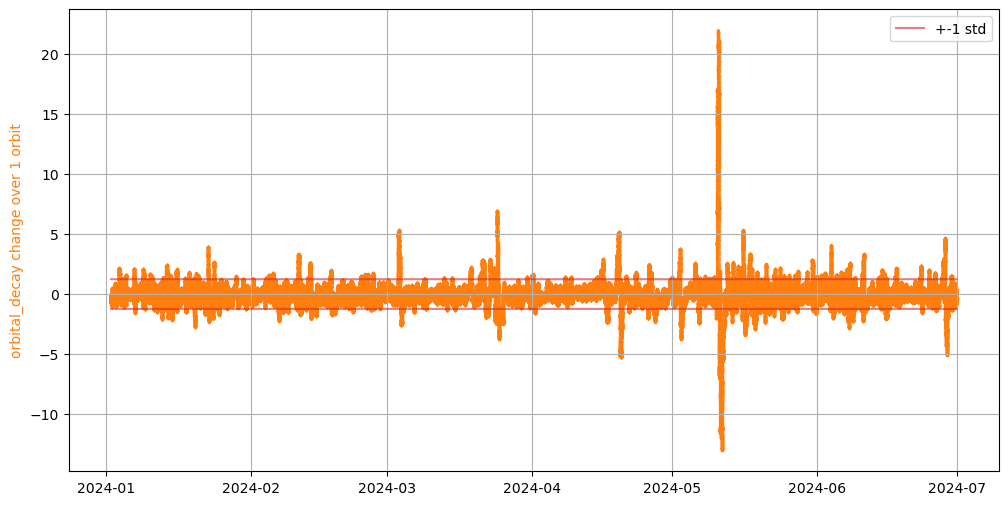

In [7]:
# print statistics about F
print("Statistics of orbital_decay change over 1 orbit:")
print(y.describe())
diff_std = y.std()
print(f"Number of points where |change| > 1*std ({1*diff_std:.4f}): {(y.abs() > 1*diff_std).sum()} out of {len(y)}")
print(f"Number of points where |change| > 2*std ({2*diff_std:.4f}): {(y.abs() > 2*diff_std).sum()} out of {len(y)}")
print(f"Number of points where |change| > 3*std ({3*diff_std:.4f}): {(y.abs() > 3*diff_std).sum()} out of {len(y)}")

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(y.index, y, s=2, c='C1', alpha=0.6)
ax.plot(y.index, [diff_std]*len(y), c='C3', alpha=0.6, label='+-1 std')
ax.plot(y.index, [-diff_std]*len(y), c='C3', alpha=0.6)
ax.grid(True)
ax.legend()
ax.set_ylabel('orbital_decay change over 1 orbit', color='C1')
plt.show()

# 3. One Orbit direct Model

### multisplit

In [52]:
class FixedRollingSplit(BaseCrossValidator):
    def __init__(self, train_size, n_splits=None, step=None, test_size=None, fixed_test_to_end=False, start=0):
        self.n_splits = n_splits
        self.train_size = train_size
        self.test_size = test_size
        self.step = step or test_size
        self.fixed_test_to_end = fixed_test_to_end
        self.start = start

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        start = self.start
        if self.n_splits is None:
            self.n_splits = n_samples // self.step

        if self.test_size is None:
            self.test_size = n_samples - self.train_size - start

        if start + self.train_size + self.test_size > n_samples:
            raise ValueError(f"Train size + test size + start must be less than the number of samples ({n_samples}). train : {self.train_size}, test : {self.test_size}, start : {start}, n_samples : {n_samples})")

        actual_n_splits = 0
        for i in range(self.n_splits):
            if start + self.train_size > n_samples:
                actual_n_splits = i
                break

            train_start = start
            train_end = train_start + self.train_size

            if not self.fixed_test_to_end:
                test_start = train_end
                test_end = test_start + self.test_size
            else:
                test_start = n_samples - self.test_size
                test_end = n_samples

            if (test_start < train_end) or (test_end > n_samples):
                actual_n_splits = i
                break

            yield np.arange(train_start, train_end), np.arange(test_start, test_end)
            start += self.step
            actual_n_splits += 1

        self.n_splits = actual_n_splits

    def get_n_splits(self, x=None, y=None, groups=None):
        return self.n_splits

In [ ]:
hour = 60 * 2  # 30s intervals
train_size, test_size = 5*24*hour, 6*hour
splitter = FixedRollingSplit(train_size=train_size,
                             test_size=test_size,
                             step=test_size)
splits = list(splitter.split(X, y))

train_idx, test_idx = splits[0]
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

In [54]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_fit = pd.DataFrame(model.predict(X_train), index=X_train.index, columns=y.columns)
y_pred = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns)

In [55]:
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import MultiTaskLasso

# pipeline = make_pipeline(
#     StandardScaler(),
#     MultiTaskLasso(alpha=0.1, warm_start=True, max_iter=500)
# )

# pipeline.fit(X_train, y_train)

# lasso = pipeline.named_steps["multitasklasso"]
# print(f'Number of non-zero coefficients: {np.sum(lasso.coef_ != 0)} out of {len(lasso.coef_)}')

In [56]:
# feature_strength = np.abs(lasso.coef_).sum(axis=0)
# feature_strength = (feature_strength > 0).astype(int)
# print(sum(feature_strength))
# # save as csv
# # pd.DataFrame({'feature': X.columns, 'importance': feature_strength}).to_csv('feature_importance.csv', index=False)

### Sanity check

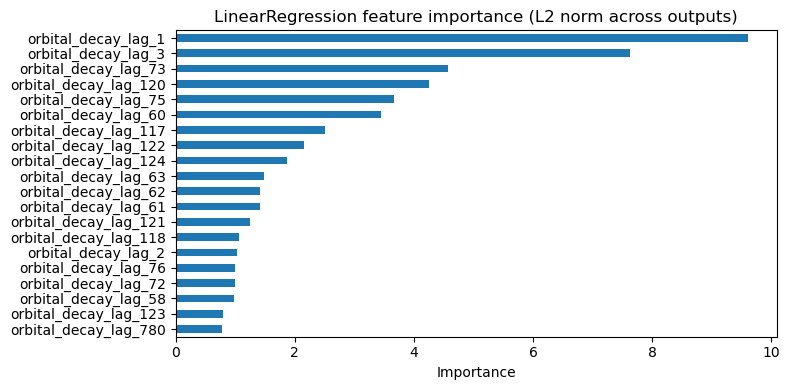

In [49]:
import numpy as np
import pandas as pd

# Feature importance for LinearRegression (handles multioutput)

# get coefficients (supports plain LinearRegression or MultiOutputRegressor-like wrappers)
if hasattr(model, "coef_"):
    coefs = model.coef_
elif hasattr(model, "estimators_"):
    # stack coefficients from wrapped estimators (e.g. MultiOutputRegressor)
    coefs = np.vstack([getattr(est, "coef_", np.zeros(len(X.columns))) for est in model.estimators_])
else:
    raise RuntimeError("Model does not expose coefficients via coef_ or estimators_")

# aggregate importance across outputs: use L2 norm across target dims
if coefs.ndim == 1:
    importance = np.abs(coefs)
else:
    importance = np.linalg.norm(coefs, axis=0)

imp_series = pd.Series(importance, index=X.columns).sort_values()

# only plot the top 20 features
imp_series = imp_series.tail(20)

fig, ax = plt.subplots(figsize=(8, max(4, len(imp_series) * 0.02)))
imp_series.plot.barh(ax=ax, color="C0")
ax.set_title("LinearRegression feature importance (L2 norm across outputs)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

Save model

In [58]:
# model_10_20 = model

## Results

In [50]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("default")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'

## Results

In [51]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

train_rmse = root_mean_squared_error(y_train, y_fit)
test_rmse = root_mean_squared_error(y_test, y_pred)
print((f"Train RMSE: {train_rmse:.3}\n" f"Test RMSE: {test_rmse:.3}"))
train_r2 = r2_score(y_train, y_fit)
test_r2 = r2_score(y_test, y_pred)
print((f"Train R2: {train_r2:.3}\n" f"Test R2: {test_r2:.3}"))

Train RMSE: 0.814
Test RMSE: 0.735
Train R2: 0.738
Test R2: 0.53


### Evolution of Error

## Plot

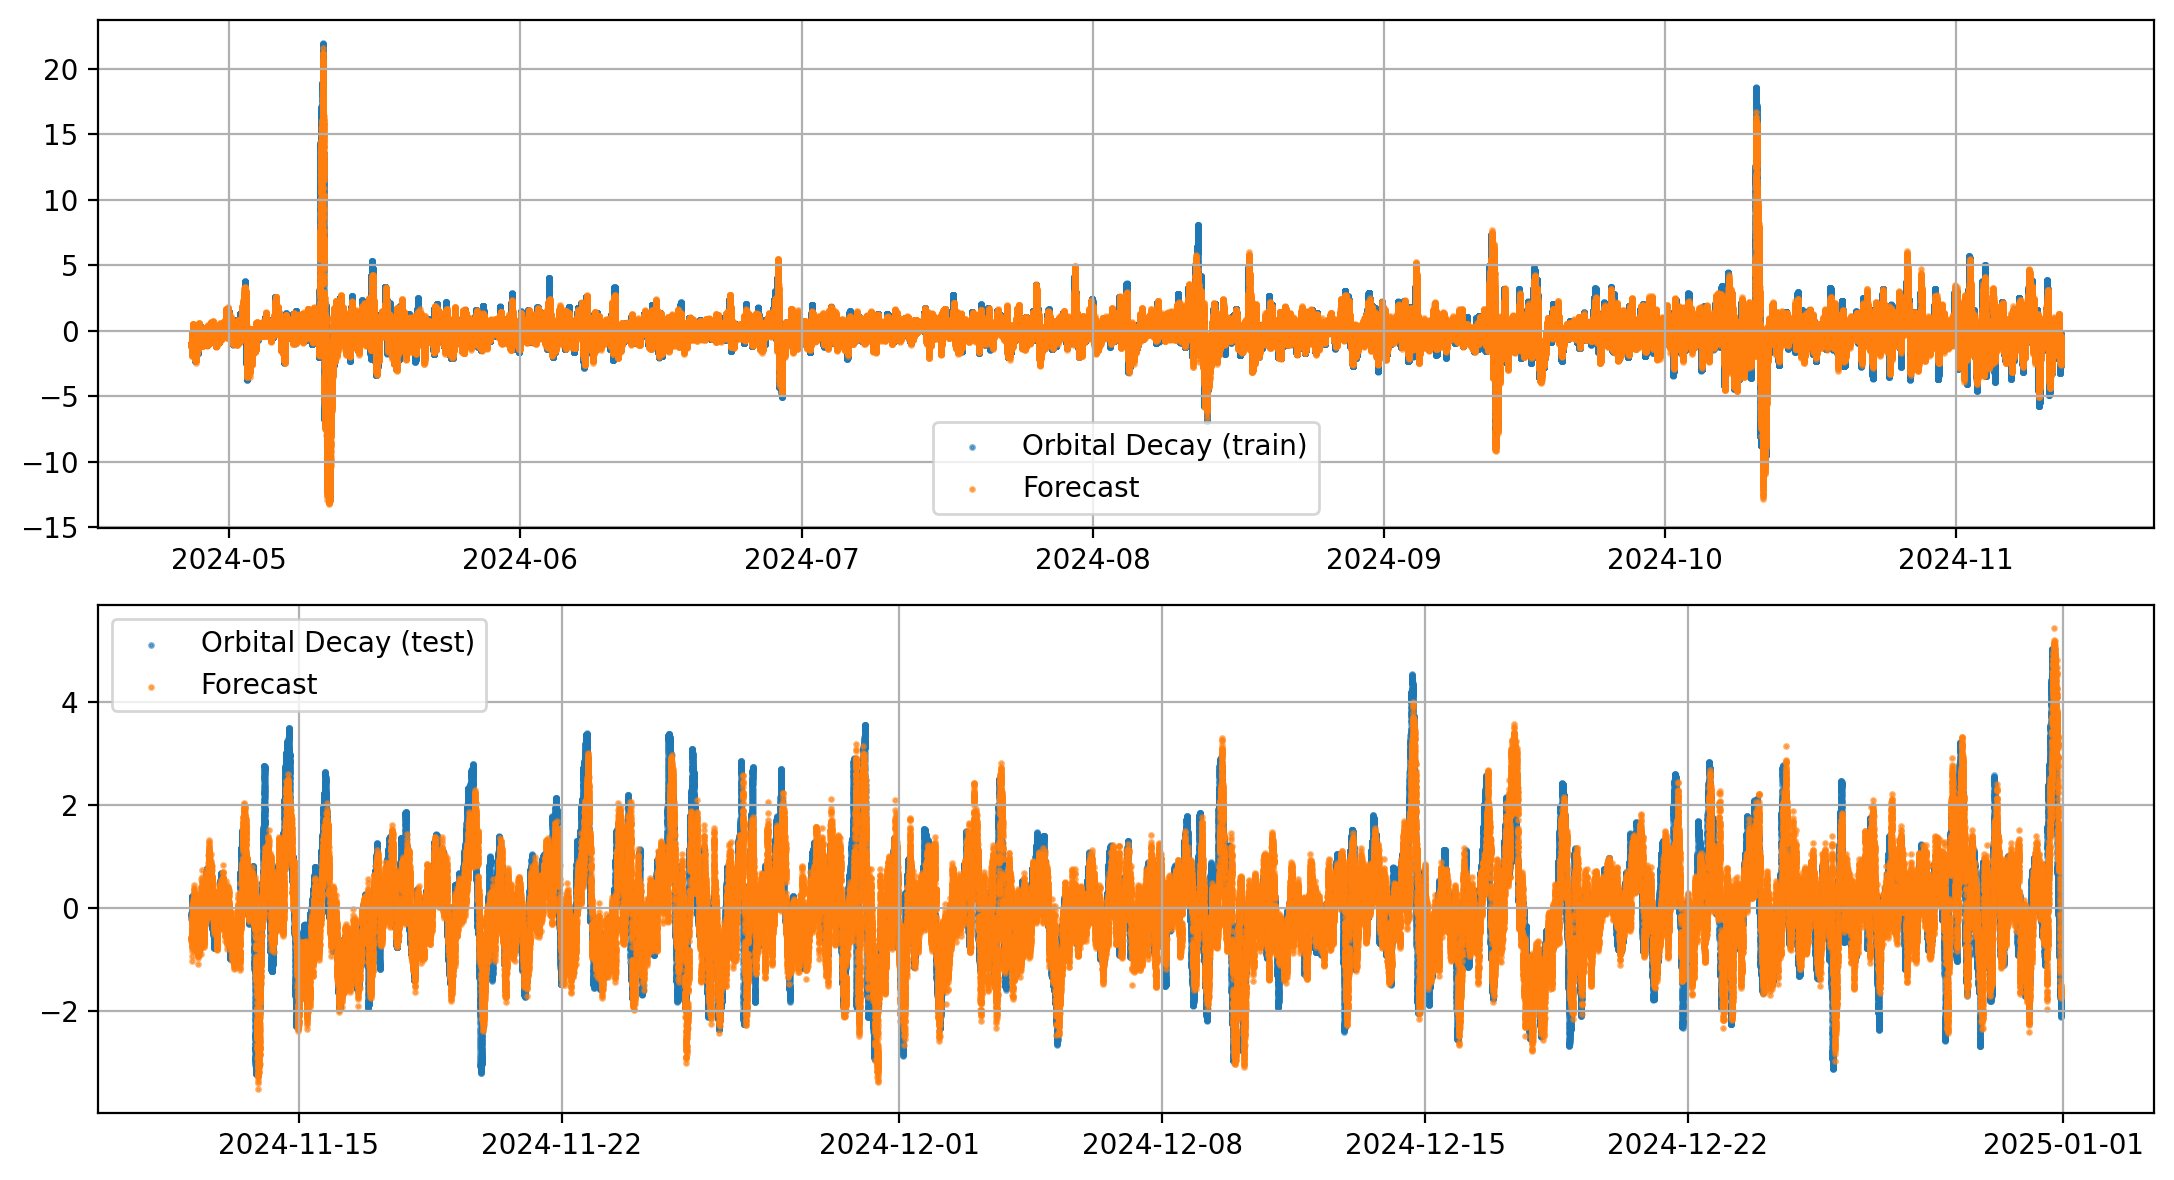

In [56]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1.scatter(y_train.index, y_train, s=2, c='C0', alpha=0.6)
ax1.scatter(y_fit.index, y_fit, s=2, c='C1', alpha=0.6)
_ = ax1.legend(['Orbital Decay (train)', 'Forecast'])
ax1.grid(True) 

ax2.scatter(y_test.index, y_test, s=2, c='C0', alpha=0.6)
ax2.scatter(y_pred.index, y_pred, s=2, c='C1', alpha=0.6)
_ = ax2.legend(['Orbital Decay (test)', 'Forecast'])
ax2.grid(True) 
plt.tight_layout()
plt.show()

In [59]:
# create masks for test using diff_std
diff_std = y.std()

test_mask_1std = (y_test.abs() < 1 * diff_std)
test_mask_2std = (y_test.abs() >= 1 * diff_std) & (y_test.abs() < 2 * diff_std)
test_mask_3std = (y_test.abs() >= 2 * diff_std) & (y_test.abs() < 3 * diff_std)
test_mask_above3std = (y_test.abs() >= 3 * diff_std)


# statistics of forecast errors
test_errors = y_test - y_pred.squeeze()

print("For <1 std deviation:")
print(test_errors[test_mask_1std].describe())
print("\nFor 1–2 std deviation:")
print(test_errors[test_mask_2std].describe())
print("\nFor 2–3 std deviation:")
print(test_errors[test_mask_3std].describe())
print("\nFor ≥3 std deviation:")
print(test_errors[test_mask_above3std].describe())

For <1 std deviation:
count    122558.000000
mean          0.042493
std           0.619182
min          -4.058925
25%          -0.346854
50%           0.040668
75%           0.429925
max           3.665046
dtype: float64

For 1–2 std deviation:
count    19142.000000
mean         0.052880
std          1.168621
min         -4.935866
25%         -0.737417
50%          0.028186
75%          0.968830
max          3.134718
dtype: float64

For 2–3 std deviation:
count    1548.000000
mean        0.815462
std         1.325072
min        -3.374960
25%         0.482725
50%         1.157549
75%         1.550631
max         3.460769
dtype: float64

For ≥3 std deviation:
count    150.000000
mean       1.096473
std        0.886479
min       -0.586867
25%        0.239011
50%        1.137564
75%        1.973428
max        2.498805
dtype: float64


## Summary

- works much better with difference, but still not great.